# KronoDroid Sequence Model Training

This notebook trains two representative sequence models on KronoDroid event-sequence traces only: BiLSTM and Transformer. The purpose is controlled representation evaluation, not a new detector architecture.

Vocabulary and padding are learned only from the KronoDroid training split.

In [10]:
# Imports and configuration
from pathlib import Path
from collections import Counter
import json
import math
import random
import time
import warnings

import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

SEED = 42
TEST_SIZE = 0.15
MAX_SEQ_LEN = 256
BATCH_SIZE = 128
EPOCHS = 20
PATIENCE = 5
LR = 1e-3
EMBED_DIM = 96
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.2

CANDIDATE_DATA_DIRS = [Path('../krono_dataset'), Path('dynamic_ieee_paper/krono_dataset'), Path('krono_dataset')]
DATA_DIR = next((p for p in CANDIDATE_DATA_DIRS if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Could not locate krono_dataset. Run from project root or dynamic_ieee_paper/deneyler.')
RESULT_DIR = Path('dynamic_ieee_paper/deneyler/results') if Path('dynamic_ieee_paper/deneyler').exists() else Path('results')
RESULT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [11]:
# Load KronoDroid sequence traces
def read_jsonl(path):
    rows = []
    with open(path, 'r') as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            seq = obj.get('seq_log', [])
            rows.append({
                'package_name': obj.get('package_name'),
                'label': obj.get('label'),
                'seq_len': obj.get('seq_len', len(seq)),
                'session_duration_ms': obj.get('session_duration_ms', 0),
                'tags': [ev.get('tag', 'UNK') for ev in seq],
                'times': [ev.get('ms', 0) for ev in seq],
            })
    return pd.DataFrame(rows)

df_ben = read_jsonl(DATA_DIR / 'krono_benign_seqlogs.jsonl')
df_mal = read_jsonl(DATA_DIR / 'krono_malware_seqlogs.jsonl')
df = pd.concat([df_ben, df_mal], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
df['label_bin'] = (df['label'] == 'malware').astype(int)

print(f'Benign : {len(df_ben):,}')
print(f'Malware: {len(df_mal):,}')
print(f'Total  : {len(df):,}')
print(df.groupby('label')['seq_len'].describe()[['min','50%','mean','max']])

Benign : 5,000
Malware: 5,000
Total  : 10,000
          min   50%     mean    max
label                              
benign   10.0  18.0  31.5912  319.0
malware  11.0  50.0  61.6072  337.0


In [12]:
# Stratified KronoDroid train/validation split
idx_train, idx_val = train_test_split(
    np.arange(len(df)), test_size=TEST_SIZE, stratify=df['label_bin'], random_state=SEED
)
train_df = df.iloc[idx_train].reset_index(drop=True)
val_df = df.iloc[idx_val].reset_index(drop=True)

# Vocabulary from train only
counter = Counter(tag for tags in train_df['tags'] for tag in tags)
itos = ['<PAD>', '<UNK>'] + sorted(counter)
stoi = {tok: i for i, tok in enumerate(itos)}
PAD_ID = stoi['<PAD>']
UNK_ID = stoi['<UNK>']
VOCAB_SIZE = len(itos)

print(f'Train: {len(train_df):,}  malware ratio={train_df.label_bin.mean():.3f}')
print(f'Val  : {len(val_df):,}  malware ratio={val_df.label_bin.mean():.3f}')
print(f'Vocabulary size: {VOCAB_SIZE} including PAD/UNK; active tags={VOCAB_SIZE-2}')
print('Top tags:', counter.most_common(12))

Train: 8,500  malware ratio=0.500
Val  : 1,500  malware ratio=0.500
Vocabulary size: 64 including PAD/UNK; active tags=62
Top tags: [('REFLECT_CLASS_LOAD', 59998), ('FILE_WRITE_INTERNAL', 37181), ('REFLECT_FIELD_ACCESS', 37042), ('NET_DNS_LOOKUP', 36783), ('CRYPTO_HASH_MD5', 27749), ('REFLECT_INVOKE', 27210), ('FILE_DELETE', 21655), ('SURV_DEVICE_ID', 20555), ('NET_HTTP_GET', 19143), ('CRYPTO_HASH_SHA', 16704), ('NET_SOCKET_TCP', 15410), ('ANTI_DEBUG', 10230)]


In [13]:
# Dataset and dataloaders
class SequenceDataset(Dataset):
    def __init__(self, frame, stoi, max_len=MAX_SEQ_LEN):
        self.frame = frame.reset_index(drop=True)
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        ids = [self.stoi.get(t, UNK_ID) for t in row['tags'][:self.max_len]]
        length = min(len(ids), self.max_len)
        if length < self.max_len:
            ids = ids + [PAD_ID] * (self.max_len - length)
        attn = [1] * length + [0] * (self.max_len - length)
        return {
            'input_ids': torch.tensor(ids, dtype=torch.long),
            'attention_mask': torch.tensor(attn, dtype=torch.float32),
            'length': torch.tensor(max(length, 1), dtype=torch.long),
            'label': torch.tensor(row['label_bin'], dtype=torch.float32),
        }

train_ds = SequenceDataset(train_df, stoi)
val_ds = SequenceDataset(val_df, stoi)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

batch = next(iter(train_dl))
print(batch['input_ids'].shape, batch['attention_mask'].shape, batch['label'].shape)

torch.Size([128, 256]) torch.Size([128, 256]) torch.Size([128])


In [14]:
# Models: BiLSTM and Transformer probes
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True, dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim * 2),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, 1),
        )

    def forward(self, input_ids, attention_mask, length):
        emb = self.embedding(input_ids)
        lengths = length.detach().cpu().clamp(min=1)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        h = torch.cat([h_n[-2], h_n[-1]], dim=1)
        return self.head(h).squeeze(1)

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, nhead=4, num_layers=2, dim_feedforward=256, dropout=DROPOUT):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        self.pos_emb = nn.Embedding(MAX_SEQ_LEN, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1),
        )

    def forward(self, input_ids, attention_mask, length):
        bsz, seqlen = input_ids.shape
        pos = torch.arange(seqlen, device=input_ids.device).unsqueeze(0).expand(bsz, seqlen)
        x = self.token_emb(input_ids) + self.pos_emb(pos)
        key_padding_mask = attention_mask == 0
        x = self.encoder(x, src_key_padding_mask=key_padding_mask)
        mask = attention_mask.unsqueeze(-1)
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        return self.head(pooled).squeeze(1)

model_factories = {
    'BiLSTM': lambda: BiLSTMClassifier(VOCAB_SIZE),
    'Transformer': lambda: TransformerClassifier(VOCAB_SIZE),
}

In [15]:
# Training and evaluation utilities
def run_epoch(model, loader, optimizer=None, criterion=None):
    train = optimizer is not None
    model.train(train)
    losses, probs, labels = [], [], []
    for batch in loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        length = batch['length'].to(DEVICE)
        y = batch['label'].to(DEVICE)
        with torch.set_grad_enabled(train):
            logits = model(input_ids, attention_mask, length)
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        losses.append(loss.item() * len(y))
        probs.extend(torch.sigmoid(logits).detach().cpu().numpy().tolist())
        labels.extend(y.detach().cpu().numpy().tolist())
    return sum(losses) / len(loader.dataset), np.array(probs), np.array(labels)

def metrics_from_probs(labels, probs, threshold=0.5):
    pred = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, pred).ravel()
    return {
        'accuracy': accuracy_score(labels, pred),
        'macro_f1': f1_score(labels, pred, average='macro'),
        'precision': precision_score(labels, pred, zero_division=0),
        'recall': recall_score(labels, pred, zero_division=0),
        'roc_auc': roc_auc_score(labels, probs),
        'pr_auc': average_precision_score(labels, probs),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    }

def train_model(name, factory):
    model = factory().to(DEVICE)
    pos_weight = torch.tensor([(len(y_train := train_df.label_bin.values) - y_train.sum()) / max(y_train.sum(), 1)], dtype=torch.float32, device=DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

    best_auc = -1.0
    best_state = None
    bad_epochs = 0
    history = []
    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        tr_loss, _, _ = run_epoch(model, train_dl, optimizer=optimizer, criterion=criterion)
        vl_loss, vl_probs, vl_labels = run_epoch(model, val_dl, criterion=criterion)
        m = metrics_from_probs(vl_labels, vl_probs)
        scheduler.step(m['roc_auc'])
        row = {'epoch': epoch, 'train_loss': tr_loss, 'val_loss': vl_loss, **m, 'seconds': time.time() - t0}
        history.append(row)
        print(f"{name} epoch {epoch:02d} | loss {tr_loss:.4f}/{vl_loss:.4f} | AUC {m['roc_auc']:.4f} | F1 {m['macro_f1']:.4f}")
        if m['roc_auc'] > best_auc:
            best_auc = m['roc_auc']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print(f'Early stopping {name} at epoch {epoch}')
                break

    model.load_state_dict(best_state)
    vl_loss, vl_probs, vl_labels = run_epoch(model, val_dl, criterion=criterion)
    final_metrics = metrics_from_probs(vl_labels, vl_probs)
    return model, pd.DataFrame(history), final_metrics, vl_probs, vl_labels

In [16]:
# Train BiLSTM and Transformer on KronoDroid
summary_rows = []
all_reports = {}
for name, factory in model_factories.items():
    print()
    print('=' * 80)
    print('Training', name)
    model, history, metrics, probs, labels = train_model(name, factory)
    history.to_csv(RESULT_DIR / f'kronodroid_sequence_{name.lower()}_history.csv', index=False)
    clean_metrics = {k: (float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v) for k, v in metrics.items()}
    torch.save({
        'model_state_dict': model.state_dict(),
        'stoi': stoi,
        'itos': itos,
        'max_seq_len': int(MAX_SEQ_LEN),
        'metrics': clean_metrics,
    }, RESULT_DIR / f'kronodroid_sequence_{name.lower()}.pt')
    row = {'model': name, **metrics}
    summary_rows.append(row)
    pred = (probs >= 0.5).astype(int)
    all_reports[name] = classification_report(labels, pred, target_names=['benign', 'malware'], output_dict=True)

results = pd.DataFrame(summary_rows).sort_values(['roc_auc', 'macro_f1'], ascending=False)
results.to_csv(RESULT_DIR / 'kronodroid_sequence_results.csv', index=False)
with open(RESULT_DIR / 'kronodroid_sequence_reports.json', 'w') as f:
    json.dump(all_reports, f, indent=2)
results


Training BiLSTM
BiLSTM epoch 01 | loss 0.3728/0.2369 | AUC 0.9643 | F1 0.9107
BiLSTM epoch 02 | loss 0.2175/0.2122 | AUC 0.9713 | F1 0.9207
BiLSTM epoch 03 | loss 0.1920/0.1694 | AUC 0.9816 | F1 0.9373
BiLSTM epoch 04 | loss 0.1519/0.1864 | AUC 0.9803 | F1 0.9400
BiLSTM epoch 05 | loss 0.1332/0.1505 | AUC 0.9853 | F1 0.9506
BiLSTM epoch 06 | loss 0.1146/0.1458 | AUC 0.9868 | F1 0.9507
BiLSTM epoch 07 | loss 0.0985/0.1319 | AUC 0.9885 | F1 0.9527
BiLSTM epoch 08 | loss 0.0799/0.1402 | AUC 0.9876 | F1 0.9567
BiLSTM epoch 09 | loss 0.0680/0.1373 | AUC 0.9885 | F1 0.9587
BiLSTM epoch 10 | loss 0.0523/0.1431 | AUC 0.9881 | F1 0.9540
BiLSTM epoch 11 | loss 0.0366/0.1511 | AUC 0.9878 | F1 0.9580
BiLSTM epoch 12 | loss 0.0242/0.1578 | AUC 0.9879 | F1 0.9600
BiLSTM epoch 13 | loss 0.0190/0.1815 | AUC 0.9868 | F1 0.9593
BiLSTM epoch 14 | loss 0.0149/0.1749 | AUC 0.9869 | F1 0.9560
Early stopping BiLSTM at epoch 14

Training Transformer
Transformer epoch 01 | loss 0.3353/0.2459 | AUC 0.9643 | F1

,model,accuracy,macro_f1,precision,recall,roc_auc,pr_auc,tn,fp,fn,tp
1,Transformer,0.962667,0.962664,0.970190,0.954667,0.990549,0.990590,728,22,34,716
0,BiLSTM,0.958667,0.958666,0.962366,0.954667,0.988544,0.989575,722,28,34,716


## Source-domain validation artifacts

This cell converts KronoDroid validation outputs into paper-friendly artifacts without overstating the result. These metrics describe source-domain validation only; temporal claims require AndroZoo inference.

,model,accuracy,macro_f1,roc_auc,pr_auc,fpr,fnr,tn,fp,fn,tp
0,Transformer,0.962667,0.962664,0.990549,0.990590,0.029333,0.045333,728,22,34,716
1,BiLSTM,0.958667,0.958666,0.988544,0.989575,0.037333,0.045333,722,28,34,716


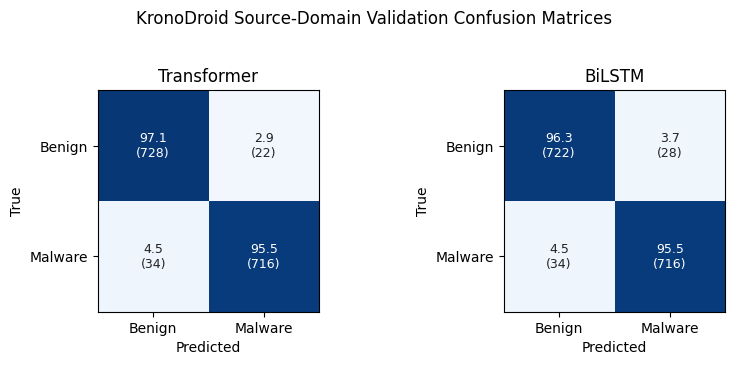

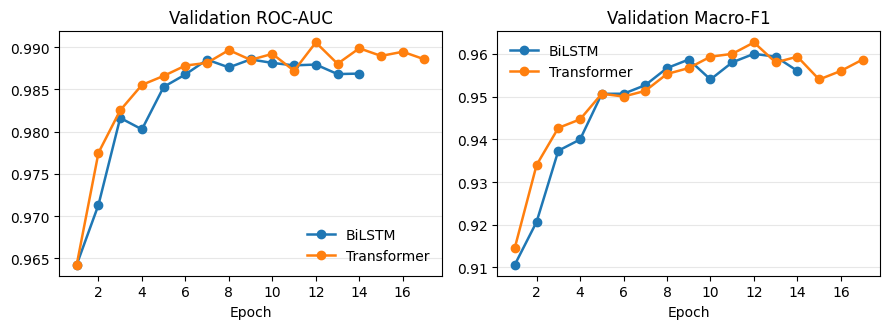

Artifacts written to: /home/tan/GitHub/paper-kangal-dynamic/dynamic_ieee_paper/deneyler/results/paper_artifacts


In [17]:
# Source-Domain Validation Artifacts
# Produces compact tables and figures for reporting KronoDroid-only validation results.
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULT_DIR = Path('dynamic_ieee_paper/deneyler/results') if Path('dynamic_ieee_paper/deneyler').exists() else Path('results')
ARTIFACT_DIR = RESULT_DIR / 'paper_artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

sequence_results = pd.read_csv(RESULT_DIR / 'kronodroid_sequence_results.csv')
sequence_results['fpr'] = sequence_results['fp'] / (sequence_results['fp'] + sequence_results['tn'])
sequence_results['fnr'] = sequence_results['fn'] / (sequence_results['fn'] + sequence_results['tp'])
report_cols = ['model', 'accuracy', 'macro_f1', 'roc_auc', 'pr_auc', 'fpr', 'fnr', 'tn', 'fp', 'fn', 'tp']
source_table = sequence_results[report_cols].copy()
source_table.to_csv(ARTIFACT_DIR / 'source_domain_sequence_validation_table.csv', index=False)
source_table.to_latex(
    ARTIFACT_DIR / 'source_domain_sequence_validation_table.tex',
    index=False,
    float_format='%.4f',
    caption='KronoDroid source-domain validation results for sequence models.',
    label='tab:source_sequence_validation'
)
display(source_table)

# Normalized confusion matrices from stored validation counts.
fig, axes = plt.subplots(1, len(source_table), figsize=(4.2 * len(source_table), 3.5))
if len(source_table) == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, source_table.iterrows()):
    cm = np.array([[row['tn'], row['fp']], [row['fn'], row['tp']]], dtype=float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0.0, vmax=1.0)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm_norm[i, j]*100:.1f}\n({int(cm[i, j])})', ha='center', va='center', color='white' if cm_norm[i, j] > 0.55 else '#222222', fontsize=9)
    ax.set_title(str(row['model']))
    ax.set_xticks([0, 1], ['Benign', 'Malware'])
    ax.set_yticks([0, 1], ['Benign', 'Malware'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
fig.suptitle('KronoDroid Source-Domain Validation Confusion Matrices', y=1.03, fontsize=12)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / 'source_domain_sequence_confusion_matrices.pdf', bbox_inches='tight')
fig.savefig(ARTIFACT_DIR / 'source_domain_sequence_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# Learning curves: validation ROC-AUC and macro-F1.
histories = []
for model_name in source_table['model']:
    hp = RESULT_DIR / f'kronodroid_sequence_{model_name.lower()}_history.csv'
    if hp.exists():
        h = pd.read_csv(hp)
        h['model'] = model_name
        histories.append(h)
if histories:
    hist_df = pd.concat(histories, ignore_index=True)
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
    for model_name, h in hist_df.groupby('model'):
        axes[0].plot(h['epoch'], h['roc_auc'], marker='o', linewidth=1.8, label=model_name)
        axes[1].plot(h['epoch'], h['macro_f1'], marker='o', linewidth=1.8, label=model_name)
    axes[0].set_title('Validation ROC-AUC')
    axes[1].set_title('Validation Macro-F1')
    for ax in axes:
        ax.set_xlabel('Epoch')
        ax.grid(True, axis='y', alpha=0.3)
        ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(ARTIFACT_DIR / 'source_domain_sequence_learning_curves.pdf', bbox_inches='tight')
    fig.savefig(ARTIFACT_DIR / 'source_domain_sequence_learning_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

print('Artifacts written to:', ARTIFACT_DIR.resolve())

## Export best sequence model for AndroZoo inference

This final cell saves a single inference bundle for the best KronoDroid validation sequence model. The bundle includes the model state, vocabulary, threshold, validation metrics, and architecture configuration required by the AndroZoo inference notebook.

In [18]:
# Export Best Sequence Model for AndroZoo Inference
# The selected model is based on KronoDroid validation ROC-AUC, not on AndroZoo performance.
import json
from pathlib import Path

import pandas as pd
import torch

RESULT_DIR = Path('dynamic_ieee_paper/deneyler/results') if Path('dynamic_ieee_paper/deneyler').exists() else Path('results')
EXPORT_DIR = RESULT_DIR / 'androzoo_inference_model'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

sequence_results = pd.read_csv(RESULT_DIR / 'kronodroid_sequence_results.csv')
best_row = sequence_results.sort_values(['roc_auc', 'macro_f1'], ascending=False).iloc[0]
best_model_name = str(best_row['model'])
source_ckpt_path = RESULT_DIR / f'kronodroid_sequence_{best_model_name.lower()}.pt'
if not source_ckpt_path.exists():
    raise FileNotFoundError(f'Missing trained checkpoint: {source_ckpt_path}')

ckpt = torch.load(source_ckpt_path, map_location='cpu', weights_only=False)

def to_builtin(value):
    if hasattr(value, 'item'):
        return value.item()
    if isinstance(value, dict):
        return {k: to_builtin(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_builtin(v) for v in value]
    return value

validation_metrics = {k: to_builtin(v) for k, v in best_row.to_dict().items()}
model_config = {
    'model_name': best_model_name,
    'max_seq_len': int(ckpt.get('max_seq_len', MAX_SEQ_LEN if 'MAX_SEQ_LEN' in globals() else 256)),
    'pad_token': '<PAD>',
    'unk_token': '<UNK>',
    'pad_id': int(ckpt['stoi']['<PAD>']),
    'unk_id': int(ckpt['stoi']['<UNK>']),
    'vocab_size': len(ckpt['itos']),
    'embed_dim': int(EMBED_DIM if 'EMBED_DIM' in globals() else 96),
    'hidden_dim': int(HIDDEN_DIM if 'HIDDEN_DIM' in globals() else 128),
    'num_layers': int(NUM_LAYERS if 'NUM_LAYERS' in globals() else 2),
    'dropout': float(DROPOUT if 'DROPOUT' in globals() else 0.2),
    'transformer_nhead': 4,
    'transformer_dim_feedforward': 256,
    'threshold': 0.5,
    'selection_metric': 'validation_roc_auc',
    'source_domain': 'KronoDroid',
    'target_domain': 'AndroZoo_2024_2026',
    'note': 'Selected using KronoDroid validation only. AndroZoo must remain inference-only for temporal evaluation.'
}

bundle = {
    'model_config': model_config,
    'model_state_dict': ckpt['model_state_dict'],
    'stoi': ckpt['stoi'],
    'itos': ckpt['itos'],
    'validation_metrics': validation_metrics,
}

bundle_path = EXPORT_DIR / 'androzoo_sequence_model_bundle.pt'
torch.save(bundle, bundle_path)
with open(EXPORT_DIR / 'sequence_vocab.json', 'w') as f:
    json.dump({'stoi': ckpt['stoi'], 'itos': ckpt['itos']}, f, indent=2)
with open(EXPORT_DIR / 'sequence_model_metadata.json', 'w') as f:
    json.dump({'model_config': model_config, 'validation_metrics': validation_metrics}, f, indent=2)

print('Selected model:', best_model_name)
print('Validation ROC-AUC:', float(best_row['roc_auc']))
print('Validation Macro-F1:', float(best_row['macro_f1']))
print('Bundle:', bundle_path.resolve())
print('Vocabulary:', (EXPORT_DIR / 'sequence_vocab.json').resolve())
print('Metadata:', (EXPORT_DIR / 'sequence_model_metadata.json').resolve())

Selected model: Transformer
Validation ROC-AUC: 0.9905493333333336
Validation Macro-F1: 0.962664277180406
Bundle: /home/tan/GitHub/paper-kangal-dynamic/dynamic_ieee_paper/deneyler/results/androzoo_inference_model/androzoo_sequence_model_bundle.pt
Vocabulary: /home/tan/GitHub/paper-kangal-dynamic/dynamic_ieee_paper/deneyler/results/androzoo_inference_model/sequence_vocab.json
Metadata: /home/tan/GitHub/paper-kangal-dynamic/dynamic_ieee_paper/deneyler/results/androzoo_inference_model/sequence_model_metadata.json
